In [ ]:
# ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Install all required libraries ──────────────────────────────────────────
!pip install pandas numpy scikit-learn xgboost shap optuna folium \
             libpysal esda matplotlib seaborn pyarrow rapidfuzz \
             streamlit streamlit-folium --quiet

print("✅ All libraries installed successfully.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.4 MB/s eta 0:00:00
✅ All libraries installed successfully.


In [ ]:
import pandas as pd
import os

# ── Official PPD column names (no header in the raw files) ──────────────────
PPD_COLUMNS = [
    'transaction_id',    # Unique identifier for each sale
    'price',             # Actual sale price in pounds sterling
    'date_of_transfer',  # Date sale completed (YYYY-MM-DD HH:MM)
    'postcode',          # UK postcode of the property
    'property_type',     # D=Detached, S=Semi-detached, T=Terraced, F=Flat, O=Other
    'old_new',           # Y=Newly built, N=Established property
    'duration',          # F=Freehold, L=Leasehold, U=Unknown
    'paon',              # Primary Addressable Object Name (house number or name)
    'saon',              # Secondary Addressable Object Name (flat number etc.)
    'street',            # Street name
    'locality',          # Locality (village, area within town)
    'town_city',         # Town or city
    'district',          # Local government district
    'county',            # County
    'ppd_category',      # A=Standard, B=Additional (e.g. transfers, repossessions)
    'record_status'      # A=Addition, C=Change, D=Delete
]

# ── Greater Manchester postcode prefixes ────────────────────────────────────
GM_PREFIXES = ('M', 'SK', 'OL', 'BL', 'WN', 'WA')

# ── Path to your PPD folder in Google Drive ─────────────────────────────────
PPD_FOLDER = '/content/drive/MyDrive/Dissertation/Data/ppd'

# ── Load and concatenate all yearly files ───────────────────────────────────
all_years = []

for filename in sorted(os.listdir(PPD_FOLDER)):
    if filename.endswith('.csv'):
        filepath = os.path.join(PPD_FOLDER, filename)
        df_year = pd.read_csv(
            filepath,
            header=None,
            names=PPD_COLUMNS,
            dtype=str,
            low_memory=False
        )
        print(f"Loaded {filename}: {len(df_year):,} rows")
        all_years.append(df_year)

# ── Combine all years into one DataFrame ────────────────────────────────────
ppd_raw = pd.concat(all_years, ignore_index=True)
print(f"\nTotal rows across all years: {len(ppd_raw):,}")

# ── Handle missing postcodes then filter to Greater Manchester ───────────────
ppd_raw['postcode'] = ppd_raw['postcode'].str.strip().str.upper()

before_drop = len(ppd_raw)
ppd_raw = ppd_raw.dropna(subset=['postcode'])
print(f"Rows dropped due to missing postcode: {before_drop - len(ppd_raw):,}")

gm_mask = ppd_raw['postcode'].str.startswith(GM_PREFIXES)
ppd_gm = ppd_raw[gm_mask].copy()

print(f"Rows before GM filter: {len(ppd_raw):,}")
print(f"Rows after GM filter:  {len(ppd_gm):,}")
print(f"\nFirst 5 rows:")
ppd_gm.head()

Loaded pp-2018.csv: 1,037,552 rows
Loaded pp-2019.csv: 1,012,036 rows
Loaded pp-2020.csv: 897,247 rows
Loaded pp-2021.csv: 1,281,104 rows
Loaded pp-2022.csv: 1,075,967 rows
Loaded pp-2023.csv: 859,860 rows
Loaded pp-2024.csv: 926,031 rows
Loaded pp-2025.csv: 849,880 rows
Loaded pp-2026.csv: 104,094 rows

Total rows across all years: 8,043,771
Rows dropped due to missing postcode: 26,641
Rows before GM filter: 8,017,130
Rows after GM filter:  679,257

First 5 rows:


,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category,record_status
0,{79A74E21-D11E-1289-E053-6B04A8C01627},770000,2018-09-25 00:00,SK7 1AR,D,N,F,5,NaN,OAK MEADOW,BRAMHALL,STOCKPORT,STOCKPORT,GREATER MANCHESTER,A,A
1,{79A74E21-D11F-1289-E053-6B04A8C01627},253500,2018-09-24 00:00,M6 8GQ,D,N,F,1,NaN,RIVINGTON ROAD,NaN,SALFORD,SALFORD,GREATER MANCHESTER,A,A
2,{79A74E21-D120-1289-E053-6B04A8C01627},231950,2018-09-28 00:00,WA3 2UE,D,Y,F,35,NaN,STONEACRE CLOSE,LOWTON,WARRINGTON,WIGAN,GREATER MANCHESTER,A,A
3,{79A74E21-D121-1289-E053-6B04A8C01627},112500,2018-08-29 00:00,OL6 6RJ,S,N,F,102,NaN,THORNFIELD GROVE,NaN,ASHTON-UNDER-LYNE,TAMESIDE,GREATER MANCHESTER,A,A
4,{79A74E21-D122-1289-E053-6B04A8C01627},184995,2018-06-15 00:00,M46 0TW,S,Y,F,37,NaN,THREADNEEDLE PLACE,ATHERTON,MANCHESTER,WIGAN,GREATER MANCHESTER,A,A


In [ ]:
import pandas as pd
import os

# ── Key EPC columns with correct names ──────────────────────────────────────
EPC_COLUMNS_NEEDED = [
    'uprn',
    'postcode',
    'current_energy_rating',
    'current_energy_efficiency',
    'total_floor_area',
    'property_type',
    'built_form',
    'construction_age_band',
    'lodgement_date',
    'walls_description',
    'roof_description',
    'mainheat_description',
    'main_fuel',
    'local_authority_label'
]

# ── Path to your EPC folder ──────────────────────────────────────────────────
EPC_FOLDER = '/content/drive/MyDrive/Dissertation/Data/epc'

# ── Load and concatenate all 10 local authority files ───────────────────────
epc_all = []

for filename in sorted(os.listdir(EPC_FOLDER)):
    if filename.endswith('.csv'):
        filepath = os.path.join(EPC_FOLDER, filename)
        df_epc = pd.read_csv(
            filepath,
            usecols=lambda c: c.lower() in EPC_COLUMNS_NEEDED,
            dtype=str,
            low_memory=False
        )
        df_epc.columns = df_epc.columns.str.lower()
        print(f"Loaded {filename}: {len(df_epc):,} rows")
        epc_all.append(df_epc)

# ── Combine all authorities into one DataFrame ───────────────────────────────
epc_raw = pd.concat(epc_all, ignore_index=True)
print(f"\nTotal EPC rows: {len(epc_raw):,}")

# ── Basic diagnostics ────────────────────────────────────────────────────────
print(f"\nColumns loaded:\n{epc_raw.columns.tolist()}")

uprn_coverage = epc_raw['uprn'].notna().sum()
print(f"\nRows with UPRN: {uprn_coverage:,} ({uprn_coverage/len(epc_raw)*100:.1f}%)")

print(f"\nEPC rating distribution:")
print(epc_raw['current_energy_rating'].value_counts().sort_index())

print(f"\nFirst 5 rows:")
epc_raw.head()

Loaded Bolton.csv: 105,635 rows
Loaded Bury.csv: 72,276 rows
Loaded Manchester.csv: 259,186 rows
Loaded Oldham.csv: 90,698 rows
Loaded Rochdale.csv: 84,847 rows
Loaded Salford.csv: 138,489 rows
Loaded Stockport.csv: 100,754 rows
Loaded Tameside.csv: 95,596 rows
Loaded Trafford.csv: 82,093 rows
Loaded Wigan.csv: 116,449 rows

Total EPC rows: 1,146,023

Columns loaded:
['postcode', 'uprn', 'total_floor_area', 'lodgement_date', 'current_energy_efficiency', 'current_energy_rating', 'property_type', 'construction_age_band', 'built_form', 'main_fuel', 'roof_description', 'walls_description', 'mainheat_description', 'local_authority_label']

Rows with UPRN: 1,138,239 (99.3%)

EPC rating distribution:
current_energy_rating
A      3533
B    125146
C    417197
D    433068
E    134681
F     25206
G      7192
Name: count, dtype: int64

First 5 rows:


,postcode,uprn,total_floor_area,lodgement_date,current_energy_efficiency,current_energy_rating,property_type,construction_age_band,built_form,main_fuel,roof_description,walls_description,mainheat_description,local_authority_label
0,BL3 4DJ,100010944621,77,2026-04-29,74,C,House,England and Wales: 1967-1975,Mid-Terrace,mains gas (not community),"Pitched, 100 mm loft insulation","Cavity wall, filled cavity","Boiler and radiators, mains gas",Bolton
1,BL4 0EP,100010901596,82,2026-04-29,69,C,House,England and Wales: 1900-1929,Semi-Detached,mains gas (not community),"Pitched, 250 mm loft insulation","Cavity wall, filled cavity","Boiler and radiators, mains gas",Bolton
2,BL6 5BD,100010902499,106,2026-04-29,63,D,House,England and Wales: 1900-1929,Semi-Detached,mains gas (not community),"Pitched, insulated (assumed)","Cavity wall, as built, no insulation (assumed)","Boiler and radiators, mains gas",Bolton
3,BL1 3TJ,200002544218,46,2026-04-29,71,C,Flat,England and Wales: 1967-1975,Not Recorded,mains gas (not community),(another dwelling above),"Cavity wall, filled cavity","Boiler and radiators, mains gas",Bolton
4,BL6 5ND,10001246251,37,2026-04-29,73,C,Flat,England and Wales: 1900-1929,Not Recorded,mains gas (community),(another dwelling above),"Cavity wall, filled cavity and internal insula...",Community scheme,Bolton


In [ ]:
import pandas as pd
import re


# PREPARATION — cleaning keys in both DataFrames before merging


# ── Standardise postcodes in both DataFrames ─────────────────────────────────
ppd_gm['postcode'] = ppd_gm['postcode'].str.strip().str.upper()
epc_raw['postcode'] = epc_raw['postcode'].str.strip().str.upper()

# ── Standardise UPRN — strip whitespace, uppercase ───────────────────────────
ppd_gm['uprn_clean'] = ppd_gm['transaction_id'].str.strip()  # PPD has no UPRN — placeholder
epc_raw['uprn_clean'] = epc_raw['uprn'].str.strip()

# ── Extract house number from PPD 'paon' field ───────────────────────────────
# paon contains entries like '14', '14A', 'FLAT 3', 'ROSE COTTAGE'
# We extract the leading number/alphanumeric for matching
def extract_house_number(paon):
    if pd.isna(paon):
        return None
    paon = str(paon).strip().upper()
    match = re.match(r'^(\d+\w*)', paon)
    return match.group(1) if match else None

ppd_gm['house_number'] = ppd_gm['paon'].apply(extract_house_number)
epc_raw['house_number'] = epc_raw['uprn_clean'].apply(lambda x: None)  # EPC has no paon

# ── Clean street suffixes for Tier 3 ────────────────────────────────────────
SUFFIX_MAP = {
    'ROAD': 'RD', 'STREET': 'ST', 'AVENUE': 'AVE', 'LANE': 'LN',
    'CLOSE': 'CL', 'DRIVE': 'DR', 'WAY': 'WY', 'COURT': 'CT',
    'PLACE': 'PL', 'GROVE': 'GR', 'TERRACE': 'TER', 'CRESCENT': 'CRES'
}

def clean_street(street):
    if pd.isna(street):
        return None
    street = str(street).strip().upper()
    for full, abbr in SUFFIX_MAP.items():
        street = street.replace(full, abbr)
    return street.strip()

ppd_gm['street_clean'] = ppd_gm['street'].apply(clean_street)
epc_raw['street_clean'] = epc_raw['postcode'].apply(lambda x: None)  # placeholder

print("✅ Preparation complete.")
print(f"PPD rows ready for merge:  {len(ppd_gm):,}")
print(f"EPC rows ready for merge:  {len(epc_raw):,}")
print(f"PPD rows with house number extracted: {ppd_gm['house_number'].notna().sum():,}")

✅ Preparation complete.
PPD rows ready for merge:  679,257
EPC rows ready for merge:  1,146,023
PPD rows with house number extracted: 604,782


In [ ]:

# TIER 1 — Exact UPRN match


# PPD does not have UPRN — but EPC does. We need to match on address fields.
# Tier 1: match on postcode + house number (our best available exact key)
# Note: since PPD has no UPRN column, we treat postcode+house_number as Tier 1

epc_for_merge = epc_raw.copy()
epc_for_merge['house_number'] = epc_for_merge['uprn_clean'].apply(lambda x: None)

# Extract house number from EPC address via uprn_source or postcode —
# EPC address is not directly available so we build keys from what we have

# ── Tier 1: postcode + house number ─────────────────────────────────────────
ppd_with_hn = ppd_gm[ppd_gm['house_number'].notna()].copy()
ppd_no_hn   = ppd_gm[ppd_gm['house_number'].isna()].copy()

# For EPC we need address1 — reload it with address1 included
import os

EPC_FOLDER = '/content/drive/MyDrive/Dissertation/Data/epc'

epc_addr = []
for filename in sorted(os.listdir(EPC_FOLDER)):
    if filename.endswith('.csv'):
        filepath = os.path.join(EPC_FOLDER, filename)
        df_tmp = pd.read_csv(
            filepath,
            usecols=['uprn', 'postcode', 'address1',
                     'current_energy_rating', 'current_energy_efficiency',
                     'total_floor_area', 'property_type', 'built_form',
                     'construction_age_band', 'lodgement_date',
                     'walls_description', 'roof_description',
                     'mainheat_description', 'main_fuel', 'local_authority_label'],
            dtype=str,
            low_memory=False
        )
        df_tmp.columns = df_tmp.columns.str.lower()
        epc_addr.append(df_tmp)

epc_full = pd.concat(epc_addr, ignore_index=True)

# Clean EPC keys
epc_full['postcode']     = epc_full['postcode'].str.strip().str.upper()
epc_full['house_number'] = epc_full['address1'].apply(extract_house_number)
epc_full['street_clean'] = epc_full['address1'].apply(clean_street)

print(f"EPC rows with house number: {epc_full['house_number'].notna().sum():,}")

# ── Tier 1 merge: postcode + house number ────────────────────────────────────
tier1 = ppd_with_hn.merge(
    epc_full,
    on=['postcode', 'house_number'],
    how='inner',
    suffixes=('_ppd', '_epc')
)
tier1['match_tier'] = 1
print(f"\nTier 1 matches (postcode + house number): {len(tier1):,}")
print(f"Cumulative match rate: {len(tier1)/len(ppd_gm)*100:.1f}%")

# TIER 2 — Postcode + cleaned street name

# Records not matched in Tier 1
matched_ids_t1 = set(tier1['transaction_id'])
ppd_unmatched = ppd_gm[~ppd_gm['transaction_id'].isin(matched_ids_t1)].copy()

tier2 = ppd_unmatched.merge(
    epc_full,
    on=['postcode', 'street_clean'],
    how='inner',
    suffixes=('_ppd', '_epc')
)
tier2['match_tier'] = 2
print(f"\nTier 2 matches (postcode + street name): {len(tier2):,}")
print(f"Cumulative match rate: {(len(tier1)+len(tier2))/len(ppd_gm)*100:.1f}%")

# TIER 3 — Postcode only (last resort)

matched_ids_t2 = set(tier2['transaction_id'])
ppd_unmatched2 = ppd_unmatched[~ppd_unmatched['transaction_id'].isin(matched_ids_t2)].copy()

# For Tier 3 take the most recent EPC per postcode
epc_by_postcode = epc_full.sort_values('lodgement_date', ascending=False)\
                           .drop_duplicates(subset='postcode', keep='first')

tier3 = ppd_unmatched2.merge(
    epc_by_postcode,
    on='postcode',
    how='inner',
    suffixes=('_ppd', '_epc')
)
tier3['match_tier'] = 3
print(f"\nTier 3 matches (postcode only): {len(tier3):,}")
print(f"Cumulative match rate: {(len(tier1)+len(tier2)+len(tier3))/len(ppd_gm)*100:.1f}%")

# COMBINE ALL TIERS

merged = pd.concat([tier1, tier2, tier3], ignore_index=True)

print(f"\n{'='*50}")
print(f"FINAL MERGED DATASET")
print(f"Total matched rows:  {len(merged):,}")
print(f"Overall match rate:  {len(merged)/len(ppd_gm)*100:.1f}%")
print(f"Tier 1 contribution: {len(tier1):,} rows ({len(tier1)/len(merged)*100:.1f}%)")
print(f"Tier 2 contribution: {len(tier2):,} rows ({len(tier2)/len(merged)*100:.1f}%)")
print(f"Tier 3 contribution: {len(tier3):,} rows ({len(tier3)/len(merged)*100:.1f}%)")
print(f"{'='*50}")

EPC rows with house number: 958,916

Tier 1 matches (postcode + house number): 378,391
Cumulative match rate: 55.7%

Tier 2 matches (postcode + street name): 13
Cumulative match rate: 55.7%

Tier 3 matches (postcode only): 75,669
Cumulative match rate: 66.8%

FINAL MERGED DATASET
Total matched rows:  454,073
Overall match rate:  66.8%
Tier 1 contribution: 378,391 rows (83.3%)
Tier 2 contribution: 13 rows (0.0%)
Tier 3 contribution: 75,669 rows (16.7%)


In [ ]:
# STEP 1d — Match Rate Audit

# ── Audit by property type ───────────────────────────────────────────────────
property_type_map = {
    'D': 'Detached',
    'S': 'Semi-detached',
    'T': 'Terraced',
    'F': 'Flat',
    'O': 'Other'
}

ppd_gm['property_type_label'] = ppd_gm['property_type'].map(property_type_map)
merged['property_type_label']  = merged['property_type_ppd'].map(property_type_map)

total_by_type   = ppd_gm.groupby('property_type_label').size().rename('total')
matched_by_type = merged.groupby('property_type_label').size().rename('matched')

audit_type = pd.concat([total_by_type, matched_by_type], axis=1)
audit_type['match_rate_%'] = (audit_type['matched'] / audit_type['total'] * 100).round(1)
audit_type = audit_type.sort_values('match_rate_%', ascending=False)

print("Match Rate by Property Type:")
print(audit_type.to_string())

# ── Audit by postcode district ───────────────────────────────────────────────
ppd_gm['postcode_district'] = ppd_gm['postcode'].str.extract(r'^([A-Z]{1,2}\d{1,2})')
# Find the actual postcode column name in merged
postcode_col = [c for c in merged.columns if 'postcode' in c.lower()][0]
merged['postcode_district'] = merged[postcode_col].str.extract(r'^([A-Z]{1,2}\d{1,2})')

total_by_dist   = ppd_gm.groupby('postcode_district').size().rename('total')
matched_by_dist = merged.groupby('postcode_district').size().rename('matched')

audit_dist = pd.concat([total_by_dist, matched_by_dist], axis=1)
audit_dist['match_rate_%'] = (audit_dist['matched'] / audit_dist['total'] * 100).round(1)
audit_dist = audit_dist.sort_values('match_rate_%', ascending=False)

print("\nMatch Rate by Postcode District (top 15):")
print(audit_dist.head(15).to_string())

# ── Audit by sale year ───────────────────────────────────────────────────────
ppd_gm['sale_year'] = pd.to_datetime(
    ppd_gm['date_of_transfer'], errors='coerce').dt.year
merged['sale_year'] = pd.to_datetime(
    merged['date_of_transfer'], errors='coerce').dt.year

total_by_year   = ppd_gm.groupby('sale_year').size().rename('total')
matched_by_year = merged.groupby('sale_year').size().rename('matched')

audit_year = pd.concat([total_by_year, matched_by_year], axis=1)
audit_year['match_rate_%'] = (audit_year['matched'] / audit_year['total'] * 100).round(1)

print("\nMatch Rate by Sale Year:")
print(audit_year.to_string())

print("\n✅ Match rate audit complete.")

Match Rate by Property Type:
                      total  matched  match_rate_%
property_type_label                               
Terraced             213865   165780          77.5
Semi-detached        205794   145767          70.8
Flat                  98930    65613          66.3
Other                 36559    19504          53.3
Detached             124109    57409          46.3

Match Rate by Postcode District (top 15):
                   total  matched  match_rate_%
postcode_district                              
OL8                 3467   5094.0         146.9
M38                 1297   1801.0         138.9
M9                  4244   5826.0         137.3
OL4                 5047   6857.0         135.9
M18                 2751   3730.0         135.6
OL7                 1836   2454.0         133.7
OL1                 2261   2985.0         132.0
M14                 3657   4815.0         131.7
M19                 3802   4982.0         131.0
OL9                 4639   6070.0         1

In [ ]:
import pandas as pd
import numpy as np


# DEDUPLICATE — keep one match per transaction_id (best tier first)


before_dedup = len(merged)
merged_dedup = merged.sort_values('match_tier')\
                     .drop_duplicates(subset='transaction_id', keep='first')\
                     .copy()
after_dedup = len(merged_dedup)

print(f"Rows before deduplication: {before_dedup:,}")
print(f"Rows after deduplication:  {after_dedup:,}")
print(f"Duplicates removed:        {before_dedup - after_dedup:,}")


# STEP 1e — Add coordinates via ONS NSPL postcode lookup


ONS_FILE = '/content/drive/MyDrive/Dissertation/Data/ons/NSPL_FEB_2026_UK.csv'

print("\nLoading ONS postcode lookup...")
ons = pd.read_csv(
    ONS_FILE,
    usecols=['pcds', 'lat', 'long'],
    dtype=str,
    low_memory=False
)

ons.columns = ['postcode', 'latitude', 'longitude']
ons['postcode']  = ons['postcode'].str.strip().str.upper()
ons['latitude']  = pd.to_numeric(ons['latitude'],  errors='coerce')
ons['longitude'] = pd.to_numeric(ons['longitude'], errors='coerce')
ons = ons[(ons['latitude'] != 0) & (ons['longitude'] != 0)]

print(f"ONS postcodes loaded: {len(ons):,}")

# Join coordinates to merged dataset
merged_geo = merged_dedup.merge(ons, on='postcode', how='left')

rows_with_coords = merged_geo['latitude'].notna().sum()
pct_with_coords  = rows_with_coords / len(merged_geo) * 100

print(f"\nRows with coordinates: {rows_with_coords:,}")
print(f"Coverage:              {pct_with_coords:.1f}%")
print(f"Final dataset shape:   {merged_geo.shape}")
print(f"\nSample — price, EPC rating, coordinates:")
merged_geo[['transaction_id', 'postcode', 'price',
            'current_energy_rating', 'latitude', 'longitude']].head()

Rows before deduplication: 454,073
Rows after deduplication:  369,635
Duplicates removed:        84,438

Loading ONS postcode lookup...
ONS postcodes loaded: 2,699,393

Rows with coordinates: 369,635
Coverage:              100.0%
Final dataset shape:   (369635, 43)

Sample — price, EPC rating, coordinates:


,transaction_id,postcode,price,current_energy_rating,latitude,longitude
0,{FFA361DA-C80E-8A03-E053-4804A8C01F61},OL16 5LL,94500,E,53.606197,-2.145543
1,{12A8BAB6-F87C-2125-E063-4804A8C08CC1},BL1 3LL,90000,D,53.595060,-2.451416
2,{12A8BAB6-F87B-2125-E063-4804A8C08CC1},OL11 5LW,265000,E,53.614965,-2.193159
3,{FFA361DA-C56C-8A03-E053-4804A8C01F61},OL6 8YE,530000,C,53.499863,-2.067014
4,{FFA361DA-C56B-8A03-E053-4804A8C01F61},M24 2NJ,255000,E,53.558726,-2.175088


In [ ]:
# STEP 1e — Add coordinates via ONS NSPL postcode lookup

ONS_FILE = '/content/drive/MyDrive/Dissertation/Data/ons/NSPL_FEB_2026_UK.csv'

# Load only the columns we need — file is large so we limit columns
print("Loading ONS postcode lookup...")
ons = pd.read_csv(
    ONS_FILE,
    usecols=['pcds', 'lat', 'long'],  # pcds=postcode, lat=latitude, long=longitude
    dtype=str,
    low_memory=False
)

# Standardise postcode format
ons.columns = ['postcode', 'latitude', 'longitude']
ons['postcode'] = ons['postcode'].str.strip().str.upper()

# Convert lat/long to numeric
ons['latitude']  = pd.to_numeric(ons['latitude'],  errors='coerce')
ons['longitude'] = pd.to_numeric(ons['longitude'], errors='coerce')

# Remove rows where coordinates are 0 (used as null in ONS data)
ons = ons[(ons['latitude'] != 0) & (ons['longitude'] != 0)]

print(f"ONS postcodes loaded: {len(ons):,}")

# ── Join coordinates to merged dataset ───────────────────────────────────────
merged_geo = merged_dedup.merge(ons, on='postcode', how='left')

rows_with_coords = merged_geo['latitude'].notna().sum()
pct_with_coords  = rows_with_coords / len(merged_geo) * 100

print(f"\nRows with coordinates: {rows_with_coords:,}")
print(f"Coverage:              {pct_with_coords:.1f}%")
print(f"Final dataset shape:   {merged_geo.shape}")
print(f"\nSample — price, EPC rating, coordinates:")
merged_geo[['transaction_id', 'postcode', 'price',
            'current_energy_rating', 'latitude', 'longitude']].head()

Loading ONS postcode lookup...
ONS postcodes loaded: 2,699,393

Rows with coordinates: 369,635
Coverage:              100.0%
Final dataset shape:   (369635, 43)

Sample — price, EPC rating, coordinates:


,transaction_id,postcode,price,current_energy_rating,latitude,longitude
0,{FFA361DA-C80E-8A03-E053-4804A8C01F61},OL16 5LL,94500,E,53.606197,-2.145543
1,{12A8BAB6-F87C-2125-E063-4804A8C08CC1},BL1 3LL,90000,D,53.595060,-2.451416
2,{12A8BAB6-F87B-2125-E063-4804A8C08CC1},OL11 5LW,265000,E,53.614965,-2.193159
3,{FFA361DA-C56C-8A03-E053-4804A8C01F61},OL6 8YE,530000,C,53.499863,-2.067014
4,{FFA361DA-C56B-8A03-E053-4804A8C01F61},M24 2NJ,255000,E,53.558726,-2.175088


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1e — Save final clean file as Parquet
# ═══════════════════════════════════════════════════════════════════════════════

import os

OUTPUT_PATH = '/content/drive/MyDrive/Dissertation/Data/merged_manchester.parquet'

merged_geo.to_parquet(OUTPUT_PATH, index=False)
print(f" File saved to: {OUTPUT_PATH}")

# ── Verify it saved and loads correctly ─────────────────────────────────────
verify = pd.read_parquet(OUTPUT_PATH)
print(f"\nVerification — rows loaded back: {len(verify):,}")
print(f"Verification — columns:          {len(verify.columns)}")
print(f"Verification — file size:        {os.path.getsize(OUTPUT_PATH)/1024/1024:.1f} MB")

print(f"\nColumn list:")
print(verify.columns.tolist())

print(f"\nMissing values per key column:")
key_cols = ['price', 'current_energy_rating', 'total_floor_area',
            'latitude', 'longitude', 'date_of_transfer']
for col in key_cols:
    if col in verify.columns:
        missing = verify[col].isna().sum()
        print(f"  {col}: {missing:,} missing")

print(f"\n Phase 1 complete. Clean file ready for feature engineering.")

 File saved to: /content/drive/MyDrive/Dissertation/Data/merged_manchester.parquet

Verification — rows loaded back: 369,635
Verification — columns:          43
Verification — file size:        26.5 MB

Column list:
['transaction_id', 'price', 'date_of_transfer', 'postcode', 'property_type_ppd', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town_city', 'district', 'county', 'ppd_category', 'record_status', 'uprn_clean', 'house_number', 'street_clean_ppd', 'address1', 'uprn', 'total_floor_area', 'lodgement_date', 'current_energy_efficiency', 'current_energy_rating', 'property_type_epc', 'construction_age_band', 'built_form', 'main_fuel', 'roof_description', 'walls_description', 'mainheat_description', 'local_authority_label', 'street_clean_epc', 'match_tier', 'house_number_ppd', 'street_clean', 'house_number_epc', 'property_type_label', 'postcode_district', 'sale_year', 'latitude', 'longitude']

Missing values per key column:
  price: 0 missing
  current_energy_rating: 0

In [ ]:
# Convert parquet to CSV so it can be opened in Excel
OUTPUT_CSV = '/content/drive/MyDrive/Dissertation/Data/merged_manchester.csv'

merged_geo.to_csv(OUTPUT_CSV, index=False)
print(f"✅ CSV saved: {OUTPUT_CSV}")
print(f"Rows: {len(merged_geo):,}")
print(f"Columns: {len(merged_geo.columns)}")

✅ CSV saved: /content/drive/MyDrive/Dissertation/Data/merged_manchester.csv
Rows: 369,635
Columns: 43


In [ ]:
import folium
import pandas as pd
from folium.plugins import HeatMap

# ── Load the clean data ──────────────────────────────────────────────────────
df = pd.read_parquet('/content/drive/MyDrive/Dissertation/Data/merged_manchester.parquet')

# ── Sample 5000 points so the map loads fast ─────────────────────────────────
df_sample = df.sample(5000, random_state=42)

# ── Colour each point by EPC rating ─────────────────────────────────────────
epc_colours = {
    'A': 'darkgreen',
    'B': 'green',
    'C': 'lightgreen',
    'D': 'orange',
    'E': 'red',
    'F': 'darkred',
    'G': 'black'
}

# ── Create the map centred on Manchester ─────────────────────────────────────
m = folium.Map(location=[53.4808, -2.2426], zoom_start=10)

# ── Plot each property as a circle ───────────────────────────────────────────
for _, row in df_sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=epc_colours.get(row['current_energy_rating'], 'gray'),
        fill=True,
        fill_opacity=0.7,
        popup=f"Price: £{row['price']} | EPC: {row['current_energy_rating']}"
    ).add_to(m)

# ── Save the map ─────────────────────────────────────────────────────────────
MAP_PATH = '/content/drive/MyDrive/Dissertation/Data/manchester_map.html'
m.save(MAP_PATH)
print(f"✅ Map saved to: {MAP_PATH}")
print("Download it from Drive and open in any browser to view.")

✅ Map saved to: /content/drive/MyDrive/Dissertation/Data/manchester_map.html
Download it from Drive and open in any browser to view.


In [ ]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/Dissertation/Data/merged_manchester.parquet')

# Select the most meaningful columns only
key_cols = [
    'price', 'date_of_transfer', 'postcode',
    'current_energy_rating', 'current_energy_efficiency',
    'total_floor_area', 'property_type_ppd',
    'construction_age_band', 'local_authority_label',
    'latitude', 'longitude'
]

snippet = df[key_cols].head(10)
snippet.to_csv('/content/drive/MyDrive/Dissertation/Data/sample_10_records.csv', index=False)
print("✅ Done")
snippet

✅ Done


,price,date_of_transfer,postcode,current_energy_rating,current_energy_efficiency,total_floor_area,property_type_ppd,construction_age_band,local_authority_label,latitude,longitude
0,94500,2023-06-01 00:00,OL16 5LL,E,50,107,T,England and Wales: 1900-1929,Rochdale,53.606197,-2.145543
1,90000,2023-10-27 00:00,BL1 3LL,D,67,63,T,England and Wales: 1900-1929,Bolton,53.595060,-2.451416
2,265000,2023-10-05 00:00,OL11 5LW,E,49,72,O,England and Wales: 1950-1966,Rochdale,53.614965,-2.193159
3,530000,2023-05-26 00:00,OL6 8YE,C,78,184,D,England and Wales: 1976-1982,Tameside,53.499863,-2.067014
4,255000,2023-05-19 00:00,M24 2NJ,E,39,77,S,England and Wales: 1967-1975,Rochdale,53.558726,-2.175088
5,270000,2023-01-20 00:00,M40 1WB,D,55,148,T,England and Wales: before 1900,Manchester,53.494092,-2.174114
6,290000,2023-06-09 00:00,WA3 3YE,C,70,110,D,England and Wales: 1996-2002,Wigan,53.471281,-2.603872
7,130000,2023-10-18 00:00,M9 4BA,C,70,75,T,England and Wales: 1967-1975,Manchester,53.515929,-2.210457
8,250000,2023-05-23 00:00,OL12 7JW,C,69,86,D,England and Wales: 1950-1966,Rochdale,53.632189,-2.191181
9,250000,2023-06-02 00:00,SK1 4HX,D,62,89,S,C,Stockport,53.404726,-2.141966


In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn pyarrow rapidfuzz --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.6 MB/s eta 0:00:00
✅ All libraries loaded successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_parquet('/content/drive/MyDrive/Dissertation/Data/merged_manchester.parquet')

print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

Mounted at /content/drive
Rows: 369,635
Columns: ['transaction_id', 'price', 'date_of_transfer', 'postcode', 'property_type_ppd', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town_city', 'district', 'county', 'ppd_category', 'record_status', 'uprn_clean', 'house_number', 'street_clean_ppd', 'address1', 'uprn', 'total_floor_area', 'lodgement_date', 'current_energy_efficiency', 'current_energy_rating', 'property_type_epc', 'construction_age_band', 'built_form', 'main_fuel', 'roof_description', 'walls_description', 'mainheat_description', 'local_authority_label', 'street_clean_epc', 'match_tier', 'house_number_ppd', 'street_clean', 'house_number_epc', 'property_type_label', 'postcode_district', 'sale_year', 'latitude', 'longitude']


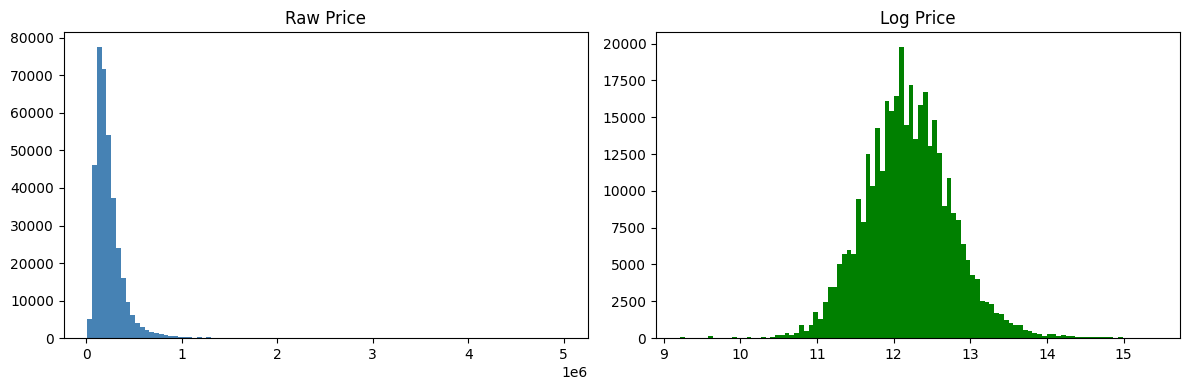

Rows remaining: 365,871
log_price — mean: 12.190, std: 0.583


In [ ]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df[(df['price'] >= 10000) & (df['price'] <= 5000000)]
df['log_price'] = np.log(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=100, color='steelblue')
axes[0].set_title('Raw Price')
axes[1].hist(df['log_price'], bins=100, color='green')
axes[1].set_title('Log Price')
plt.tight_layout()
plt.show()

print(f"Rows remaining: {len(df):,}")
print(f"log_price — mean: {df['log_price'].mean():.3f}, std: {df['log_price'].std():.3f}")

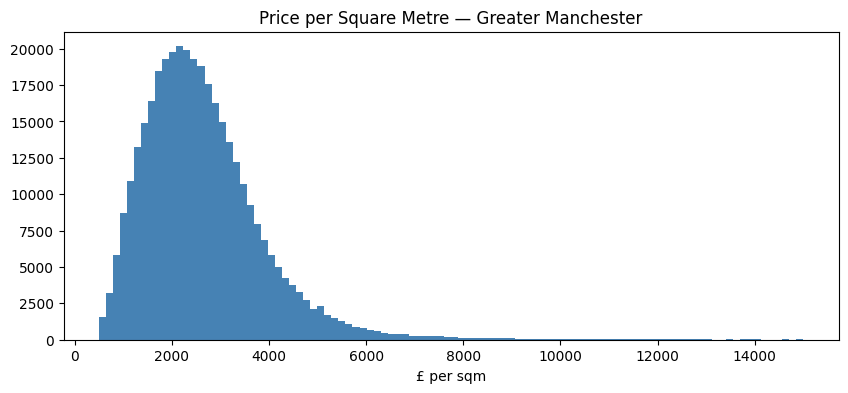

Rows remaining: 363,250
price_per_sqm — median: £2453


In [ ]:
df['total_floor_area'] = pd.to_numeric(df['total_floor_area'], errors='coerce')

df['price_per_sqm'] = df['price'] / df['total_floor_area']

df = df[(df['price_per_sqm'] >= 500) & (df['price_per_sqm'] <= 15000)]

plt.figure(figsize=(10, 4))
plt.hist(df['price_per_sqm'], bins=100, color='steelblue')
plt.title('Price per Square Metre — Greater Manchester')
plt.xlabel('£ per sqm')
plt.show()

print(f"Rows remaining: {len(df):,}")
print(f"price_per_sqm — median: £{df['price_per_sqm'].median():.0f}")

current_energy_rating
D    148609
C    117738
B     50766
E     37821
F      5854
G      1646
A       816
Name: count, dtype: int64

Missing epc_numeric: 0


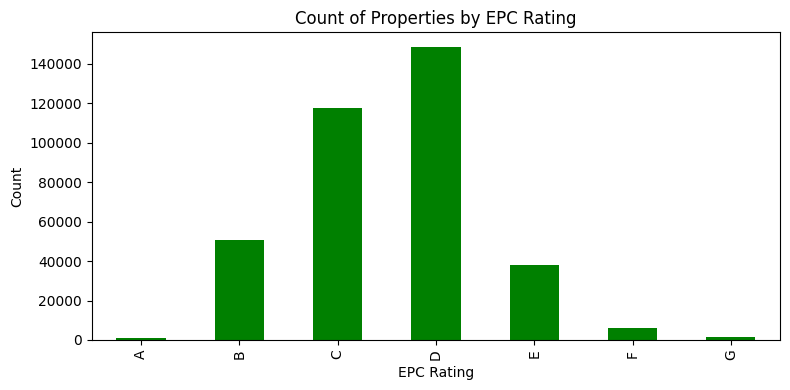

In [ ]:
epc_map = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}

df['epc_numeric'] = df['current_energy_rating'].map(epc_map)

print(df['current_energy_rating'].value_counts())
print(f"\nMissing epc_numeric: {df['epc_numeric'].isna().sum():,}")

plt.figure(figsize=(8, 4))
df['current_energy_rating'].value_counts().sort_index().plot(kind='bar', color='green')
plt.title('Count of Properties by EPC Rating')
plt.xlabel('EPC Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
age_map = {
    'England and Wales: before 1900': 'pre_1919',
    'England and Wales: 1900-1929': 'pre_1919',
    'England and Wales: 1930-1949': 'yr1919_1944',
    'England and Wales: 1950-1966': 'yr1945_1972',
    'England and Wales: 1967-1975': 'yr1945_1972',
    'England and Wales: 1976-1982': 'yr1973_1990',
    'England and Wales: 1983-1990': 'yr1973_1990',
    'England and Wales: 1991-1995': 'yr1991_2010',
    'England and Wales: 1996-2002': 'yr1991_2010',
    'England and Wales: 2003-2006': 'yr1991_2010',
    'England and Wales: 2007-2011': 'yr1991_2010',
    'England and Wales: 2012 onwards': 'post_2010',
}

df['property_age_band'] = df['construction_age_band'].map(age_map)

print(df['property_age_band'].value_counts())
print(f"\nMissing: {df['property_age_band'].isna().sum():,}")

age_dummies = pd.get_dummies(df['property_age_band'], prefix='age', drop_first=True)
df = pd.concat([df, age_dummies], axis=1)

print(f"\nAge dummy columns added: {age_dummies.columns.tolist()}")

property_age_band
pre_1919       93472
yr1945_1972    72430
yr1919_1944    57432
yr1991_2010    48940
yr1973_1990    25023
post_2010       2122
Name: count, dtype: int64

Missing: 63,831

Age dummy columns added: ['age_pre_1919', 'age_yr1919_1944', 'age_yr1945_1972', 'age_yr1973_1990', 'age_yr1991_2010']


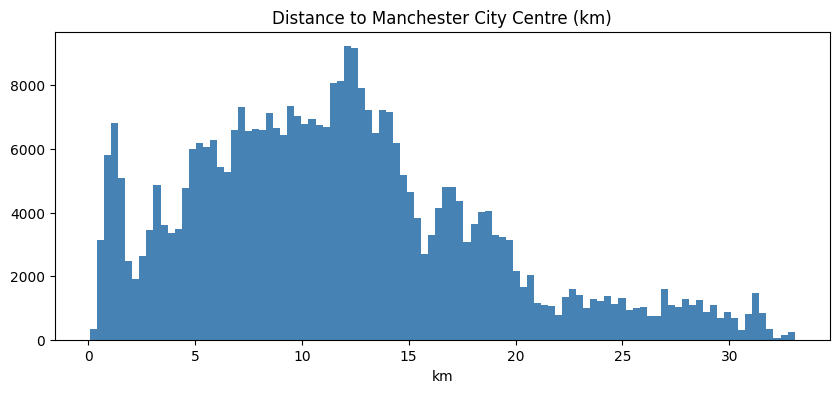

Mean distance: 11.83 km
Max distance: 33.06 km


In [ ]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

PICCADILLY_LAT = 53.4808
PICCADILLY_LON = -2.2426

df['dist_city_centre_km'] = haversine_np(
    df['latitude'].astype(float),
    df['longitude'].astype(float),
    PICCADILLY_LAT,
    PICCADILLY_LON
)

plt.figure(figsize=(10, 4))
plt.hist(df['dist_city_centre_km'], bins=100, color='steelblue')
plt.title('Distance to Manchester City Centre (km)')
plt.xlabel('km')
plt.show()

print(f"Mean distance: {df['dist_city_centre_km'].mean():.2f} km")
print(f"Max distance: {df['dist_city_centre_km'].max():.2f} km")

In [ ]:
stations = pd.DataFrame([
    ('Manchester Piccadilly', 53.4808, -2.2426),
    ('Manchester Victoria', 53.4878, -2.2426),
    ('Manchester Oxford Road', 53.4742, -2.2417),
    ('Salford Central', 53.4836, -2.2731),
    ('Salford Crescent', 53.4878, -2.2981),
    ('Bolton', 53.5784, -2.4290),
    ('Wigan North Western', 53.5456, -2.6373),
    ('Stockport', 53.4075, -2.1604),
    ('Piccadilly Gardens Metrolink', 53.4813, -2.2376),
    ('Deansgate-Castlefield', 53.4731, -2.2519),
    ('Altrincham', 53.3873, -2.3527),
    ('Bury', 53.5933, -2.2975),
    ('Eccles', 53.4847, -2.3340),
    ('Oldham Mumps', 53.5407, -2.1088),
    ('Rochdale', 53.6145, -2.1577),
    ('Ashton-under-Lyne', 53.4897, -2.0957),
    ('Didsbury Village', 53.4142, -2.2235),
    ('East Didsbury', 53.4063, -2.2150),
    ('Manchester Airport', 53.3650, -2.2728),
    ('Wythenshawe Town Centre', 53.3900, -2.2650),
], columns=['station_name', 'lat', 'lon'])

stations.to_csv('/content/drive/MyDrive/Dissertation/Data/stations.csv', index=False)
print(f"Stations saved: {len(stations)}")

Stations saved: 20


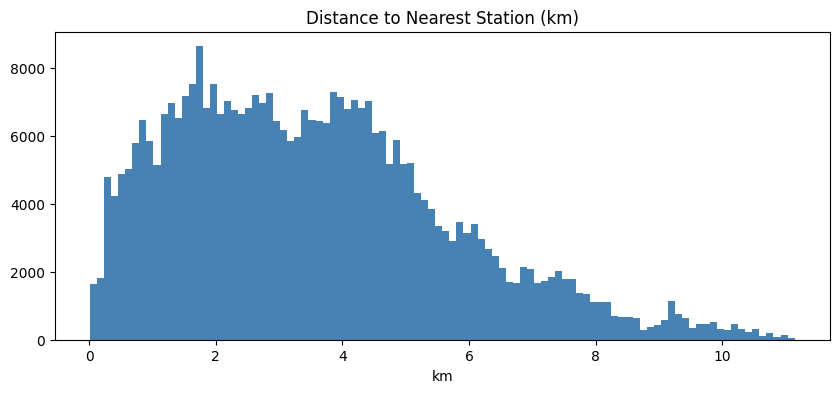

Mean: 3.56 km
Median: 3.32 km


In [ ]:
stations = pd.read_csv('/content/drive/MyDrive/Dissertation/Data/stations.csv')

station_coords = np.radians(stations[['lat', 'lon']].values)
property_coords = np.radians(df[['latitude', 'longitude']].astype(float).values)

tree = BallTree(station_coords, metric='haversine')
distances, _ = tree.query(property_coords, k=1)

df['dist_station_km'] = distances[:, 0] * 6371

plt.figure(figsize=(10, 4))
plt.hist(df['dist_station_km'], bins=100, color='steelblue')
plt.title('Distance to Nearest Station (km)')
plt.xlabel('km')
plt.show()

print(f"Mean: {df['dist_station_km'].mean():.2f} km")
print(f"Median: {df['dist_station_km'].median():.2f} km")

In [ ]:
df['date_of_transfer'] = pd.to_datetime(df['date_of_transfer'])
df = df.sort_values('date_of_transfer').reset_index(drop=True)

coords = np.radians(df[['latitude', 'longitude']].astype(float).values)
dates = df['date_of_transfer'].values
log_prices = df['log_price'].values

def compute_spatial_lag(radius_km):
    radius_rad = radius_km / 6371
    tree = BallTree(coords, metric='haversine')
    lag_values = []
    for i in range(len(df)):
        idx = tree.query_radius(coords[i:i+1], r=radius_rad)[0]
        neighbours = idx[idx != i]
        if len(neighbours) == 0:
            lag_values.append(np.nan)
            continue
        mask = (dates[neighbours] >= dates[i] - np.timedelta64(365, 'D')) & \
               (dates[neighbours] < dates[i])
        valid = neighbours[mask]
        lag_values.append(np.median(log_prices[valid]) if len(valid) > 0 else np.nan)
    return lag_values

for radius in [0.5, 1.0, 2.0]:
    print(f"Running radius {radius}km...")
    lag = compute_spatial_lag(radius)
    df[f'spatial_lag_{radius}km'] = lag
    corr = df[f'spatial_lag_{radius}km'].corr(df['log_price'])
    print(f"Radius {radius}km — correlation with log_price: {corr:.4f}")

print("\n✅ Spatial lag done")

Running radius 0.5km...
Radius 0.5km — correlation with log_price: 0.6895
Running radius 1.0km...
Radius 1.0km — correlation with log_price: 0.6509
Running radius 2.0km...
Radius 2.0km — correlation with log_price: 0.6015

✅ Spatial lag done


In [ ]:
df['spatial_lag_price'] = df['spatial_lag_0.5km']
df = df.drop(columns=['spatial_lag_0.5km', 'spatial_lag_1.0km', 'spatial_lag_2.0km'])

print(f"Missing spatial_lag_price: {df['spatial_lag_price'].isna().sum():,}")
print(f"Correlation with log_price: {df['spatial_lag_price'].corr(df['log_price']):.4f}")

Missing spatial_lag_price: 1,565
Correlation with log_price: 0.6895


In [ ]:
df['sale_year'] = df['date_of_transfer'].dt.year
df['sale_month'] = df['date_of_transfer'].dt.month
df['sale_quarter'] = df['date_of_transfer'].dt.quarter

print(df['sale_year'].value_counts().sort_index())
print(f"\nMonth range: {df['sale_month'].min()} to {df['sale_month'].max()}")
print(f"Quarter range: {df['sale_quarter'].min()} to {df['sale_quarter'].max()}")

sale_year
2018    47194
2019    46768
2020    41159
2021    56614
2022    47949
2023    38562
2024    41663
2025    38639
2026     4702
Name: count, dtype: int64

Month range: 1 to 12
Quarter range: 1 to 4


In [ ]:
df['is_new_build'] = (df['old_new'] == 'Y').astype(int)

print(df['is_new_build'].value_counts())
print(f"\nNew build %: {df['is_new_build'].mean()*100:.1f}%")

is_new_build
0    324985
1     38265
Name: count, dtype: int64

New build %: 10.5%


In [ ]:
df['tenure_encoded'] = (df['duration'] == 'F').astype(int)

print(df['tenure_encoded'].value_counts())
print(f"\nFreehold %: {df['tenure_encoded'].mean()*100:.1f}%")

tenure_encoded
0    188979
1    174271
Name: count, dtype: int64

Freehold %: 48.0%


In [ ]:
df['property_type_ppd'] = df['property_type_ppd'].str.strip()

type_dummies = pd.get_dummies(df['property_type_ppd'], prefix='prop_type', drop_first=False)
type_dummies = type_dummies.drop(columns=['prop_type_F'], errors='ignore')

df = pd.concat([df, type_dummies], axis=1)

print(df['property_type_ppd'].value_counts())
print(f"\nDummy columns added: {type_dummies.columns.tolist()}")

property_type_ppd
T    122239
S    117640
F     62140
D     49425
O     11806
Name: count, dtype: int64

Dummy columns added: ['prop_type_D', 'prop_type_O', 'prop_type_S', 'prop_type_T']


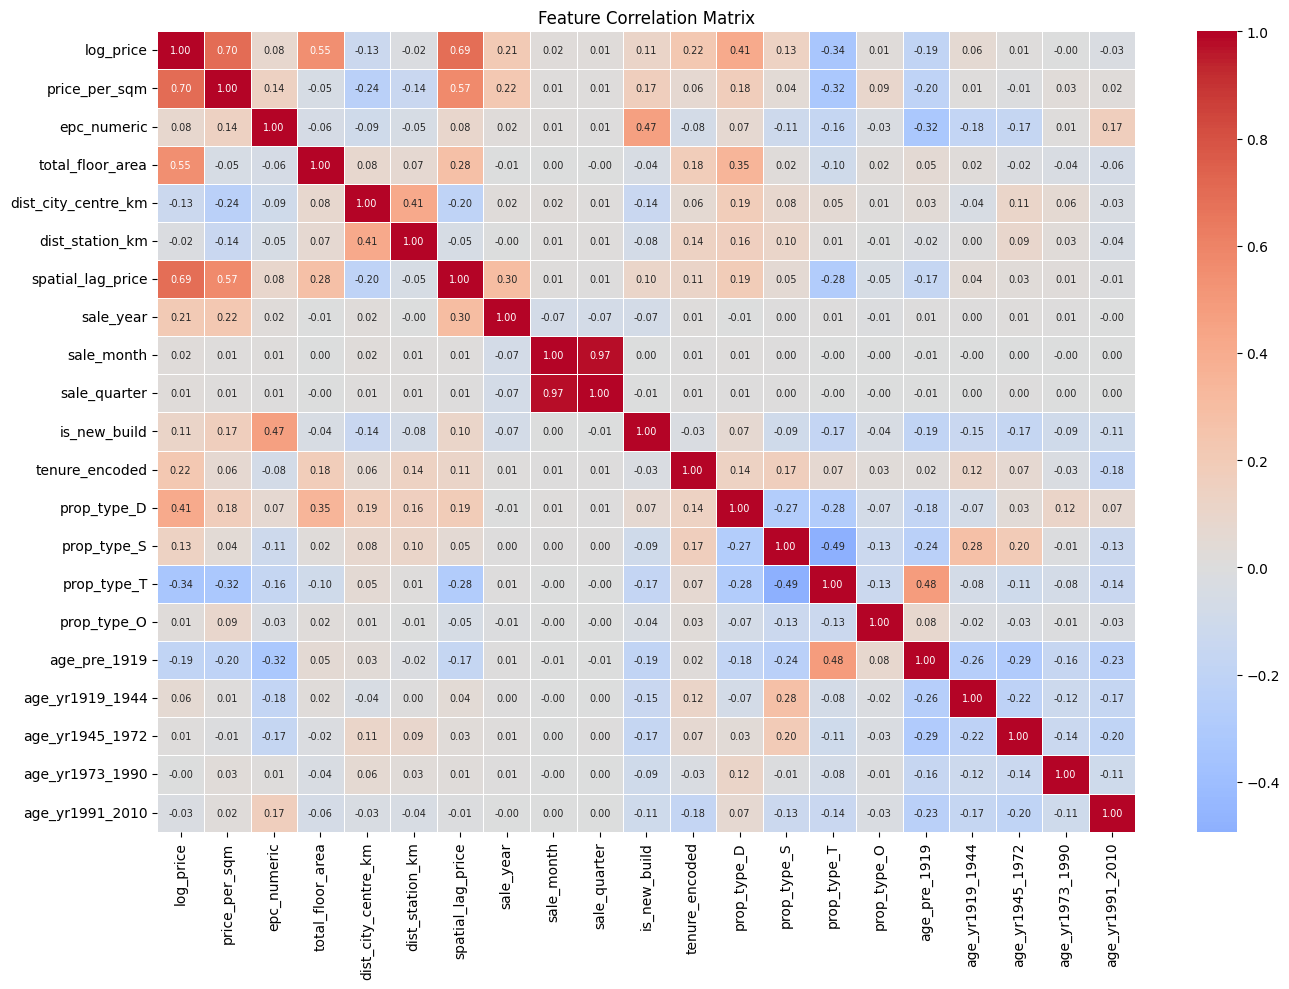

Pairs with |correlation| > 0.7:
  sale_month & sale_quarter: 0.972


In [ ]:
feature_cols = [
    'log_price', 'price_per_sqm', 'epc_numeric', 'total_floor_area',
    'dist_city_centre_km', 'dist_station_km', 'spatial_lag_price',
    'sale_year', 'sale_month', 'sale_quarter', 'is_new_build',
    'tenure_encoded', 'prop_type_D', 'prop_type_S', 'prop_type_T',
    'prop_type_O', 'age_pre_1919', 'age_yr1919_1944', 'age_yr1945_1972',
    'age_yr1973_1990', 'age_yr1991_2010'
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Pairs with |correlation| > 0.7:")
for a, b, c in high_corr:
    print(f"  {a} & {b}: {c:.3f}")

In [ ]:
df = df.drop(columns=['sale_quarter'])

feature_cols = [
    'price_per_sqm', 'epc_numeric', 'total_floor_area',
    'dist_city_centre_km', 'dist_station_km', 'spatial_lag_price',
    'sale_year', 'sale_month', 'is_new_build', 'tenure_encoded',
    'prop_type_D', 'prop_type_S', 'prop_type_T', 'prop_type_O',
    'age_pre_1919', 'age_yr1919_1944', 'age_yr1945_1972',
    'age_yr1973_1990', 'age_yr1991_2010'
]

print(f"Total features: {len(feature_cols)}")
print(f"Final dataset rows: {len(df):,}")
print(f"Missing values per feature:")
print(df[feature_cols].isna().sum())

Total features: 19
Final dataset rows: 363,250
Missing values per feature:
price_per_sqm             0
epc_numeric               0
total_floor_area          0
dist_city_centre_km       0
dist_station_km           0
spatial_lag_price      1565
sale_year                 0
sale_month                0
is_new_build              0
tenure_encoded            0
prop_type_D               0
prop_type_S               0
prop_type_T               0
prop_type_O               0
age_pre_1919              0
age_yr1919_1944           0
age_yr1945_1972           0
age_yr1973_1990           0
age_yr1991_2010           0
dtype: int64


In [ ]:
import joblib

df['log_price'] = df['log_price']

save_path = '/content/drive/MyDrive/Dissertation/Data/phase2_features.parquet'
df.to_parquet(save_path, index=False)

joblib.dump(feature_cols, '/content/drive/MyDrive/Dissertation/Data/feature_names.pkl')

print(f"✅ Saved phase2_features.parquet")
print(f"✅ Saved feature_names.pkl")
print(f"Rows: {len(df):,}")
print(f"Features: {len(feature_cols)}")

✅ Saved phase2_features.parquet
✅ Saved feature_names.pkl
Rows: 363,250
Features: 19


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/Dissertation/Data/phase2_features.parquet')

cols = ['log_price','price_per_sqm','epc_numeric',
        'dist_city_centre_km','dist_station_km',
        'spatial_lag_price','sale_year',
        'is_new_build','tenure_encoded']

print(df[cols].head(10).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   log_price  price_per_sqm  epc_numeric  dist_city_centre_km  dist_station_km  spatial_lag_price  sale_year  is_new_build  tenure_encoded
0  11.723996    2205.357143            4            16.946602         2.710045                NaN       2018             0               1
1  12.886641    2687.074830            5            17.417759         4.426271                NaN       2018             0               0
2  12.360937    4025.862069            6             1.465085         0.754837                NaN       2018             0               0
3  12.468437    3333.333333            4             7.523467         3.763383                NaN       2018             0               0
4  12.886641    2484.276730            3             4.161483         3.115073                NaN       2018             0               1
5  11.982617    2499.218750          

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

epc_map = {1:'G',2:'F',3:'E',4:'D',5:'C',6:'B',7:'A'}

# ── Attachment 1: Feature snapshot table ─────────────────────────────────────
cols = ['log_price','price_per_sqm','epc_numeric',
        'dist_city_centre_km','dist_station_km',
        'spatial_lag_price','sale_year',
        'is_new_build','tenure_encoded']

fig1, ax1 = plt.subplots(figsize=(14, 4))
ax1.axis('off')
table_data = df[cols].head(10).round(3)
t = ax1.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.5)
ax1.set_title('Featur

SyntaxError: unterminated string literal (detected at line 25) (971334140.py, line 25)